In [1]:
# Colab bootstrap — auto-clone repo on Google Colab, no-op locally
import os, sys, subprocess

REPO = "https://github.com/jongmoonha/AI-PHM_Graduate.git"
DIR  = "AI-PHM_Graduate"

try:
    import google.colab  # type: ignore
    target = '/content/' + DIR
    if not os.path.isdir(target):
        subprocess.run(["git", "clone", REPO, target], check=True)
    os.chdir(target)
    print('Google Colab detected. Working directory:', os.getcwd())
except ImportError:
    print('Local environment detected. Working directory:', os.getcwd())


Local environment detected. Working directory: C:\Users\User\OneDrive\00_수업 관련 업무\00_참고자료\신호처리 Lecture Note_v2\Signal_Processing_Practice_from_Basics_to_Advanced


# 시간-주파수 분석: STFT와 웨이블릿 변환

## 학습 목표
- 시변 주파수 신호에 대한 FFT 의 한계와 STFT 슬라이딩 윈도우 원리를 본다
- `scipy.signal.spectrogram` 의 `nperseg`, `noverlap`, `nfft` 파라미터 영향을 비교한다
- CWT (Morlet) 의 다중해상도 특성과 DWT 디노이징을 다룬다

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from utils import fft

---

## 실습 1. chirp와 FFT의 한계

시간에 따라 주파수가 변하는 **chirp 신호**를 만들고 일반 FFT 를 적용해 본다. FFT 는 전 구간의 주파수 성분을 한꺼번에 보여 주므로 **어느 시점에 어떤 주파수가 있었는지**는 알 수 없다. 이것이 시간-주파수 분석이 필요한 이유다.

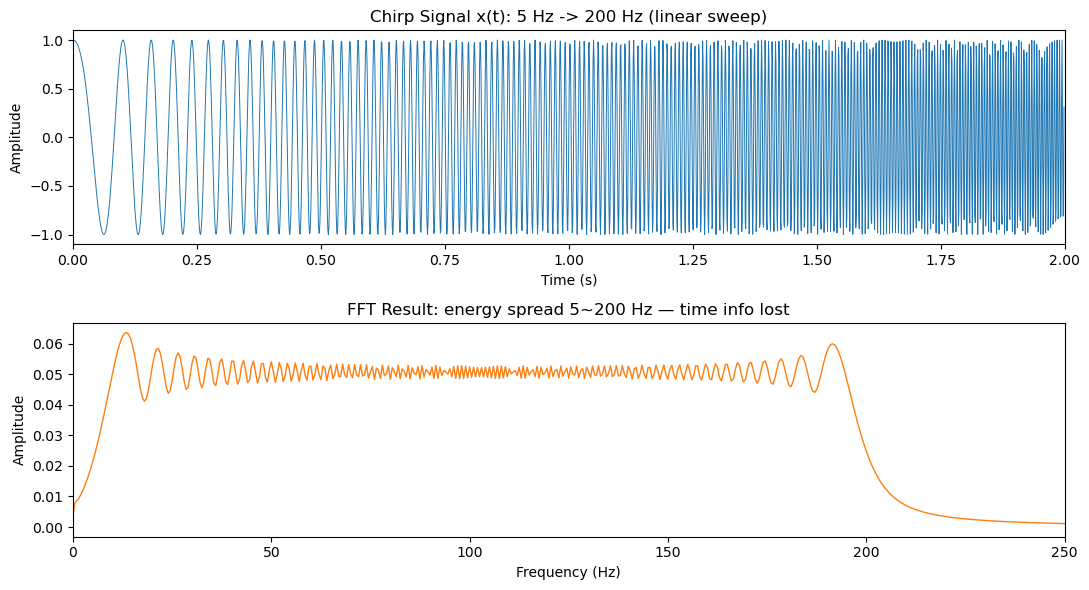

In [3]:
# 선형 chirp 생성: 5 Hz -> 200 Hz, fs=1000 Hz, 2초
fs = 1000
T = 2.0
t = np.arange(0, T, 1 / fs)
x = signal.chirp(t, f0=5, f1=200, t1=T, method='linear')

# FFT (단측 진폭 스펙트럼)
f_axis, A = fft(x, fs)

fig, axes = plt.subplots(2, 1, figsize=(11, 6))
axes[0].plot(t, x, color='C0', linewidth=0.7)
axes[0].set_title('Chirp Signal x(t): 5 Hz -> 200 Hz (linear sweep)')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_xlim([0, T])

axes[1].plot(f_axis, A, color='C1', linewidth=1.0)
axes[1].set_title('FFT Result: energy spread 5~200 Hz — time info lost')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlim([0, 250])
plt.tight_layout()
plt.show()

FFT 결과는 5~200 Hz 전 구간에 에너지가 고르게 퍼져 있을 뿐, **어느 시점에** 저주파/고주파가 있었는지 알 수 없다.

### 직접 해보기
1. `f1=500`으로 끝 주파수를 높이면 FFT 스펙트럼은 어떻게 변하는가?
2. `f0=f1=100`으로 고정 주파수 신호를 만들면 스펙트럼에 단일 피크가 나타나는가?

---

## 실습 2. 슬라이딩 윈도우 원리

STFT 는 신호를 **짧은 프레임**으로 잘라 각 프레임마다 윈도우를 곱한 뒤 FFT 를 수행한다. Hann 윈도우가 프레임 양 끝을 부드럽게 눌러 스펙트럼 누설을 줄인다.

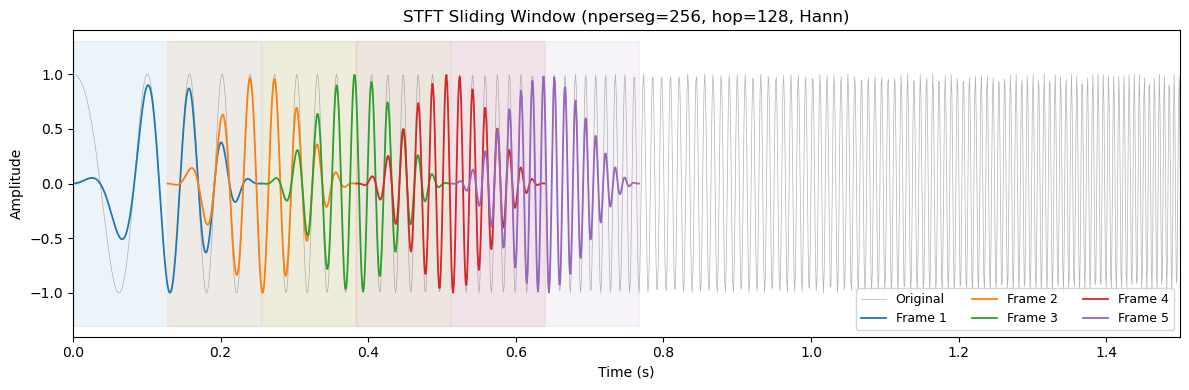

In [4]:
nperseg = 256
hop = 128  # 50% 오버랩
win = signal.windows.hann(nperseg)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, x, color='gray', linewidth=0.5, alpha=0.6, label='Original')

frame_colors = ['C0', 'C1', 'C2', 'C3', 'C4']
positions = [i * hop for i in range(5)]
for i, pos in enumerate(positions):
    if pos + nperseg > len(x):
        break
    tw = t[pos:pos + nperseg]
    xw = x[pos:pos + nperseg] * win
    ax.fill_between(tw, -1.3, 1.3, color=frame_colors[i], alpha=0.08)
    ax.plot(tw, xw, color=frame_colors[i], linewidth=1.3,
            label=f'Frame {i+1}')

ax.set_title(f'STFT Sliding Window (nperseg={nperseg}, hop={hop}, Hann)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_xlim([0, 1.5])
ax.set_ylim([-1.4, 1.4])
ax.legend(loc='lower right', ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

각 프레임은 Hann 윈도우가 적용되어 중앙이 강하고 끝이 약하다. 이를 이용해 각 프레임에서 독립적으로 FFT를 수행한다.

---

## 실습 3. 첫 스펙트로그램

프레임마다의 FFT 결과를 시간축·주파수축 2D 로 펼친 것이 **스펙트로그램**이다. chirp 신호의 궤적이 밝은 사선으로 드러난다.

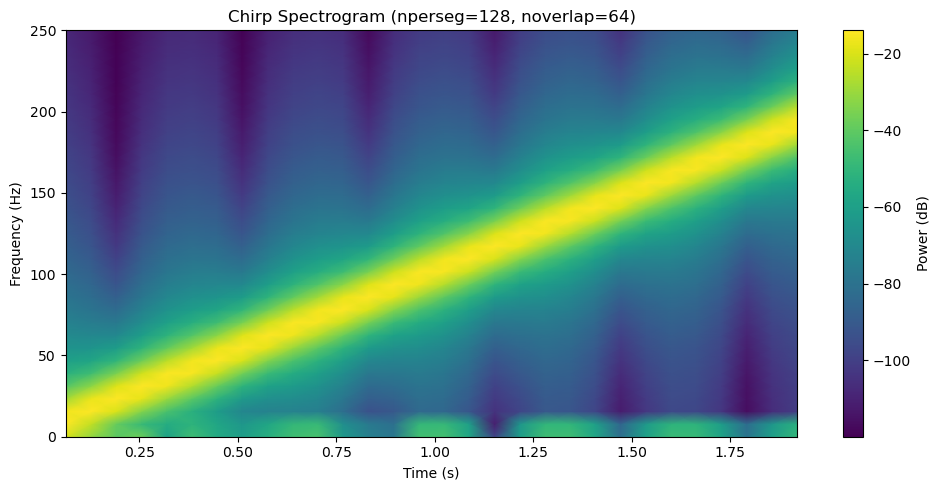

In [5]:
nperseg = 128
noverlap = nperseg // 2
nfft = nperseg

f, t_spec, Sxx = signal.spectrogram(
    x, fs=fs, nperseg=nperseg, noverlap=noverlap, nfft=nfft, window='hann')

fig, ax = plt.subplots(figsize=(10, 5))
pcm = ax.pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-12),
                    shading='gouraud', cmap='viridis')
ax.set_title(f'Chirp Spectrogram (nperseg={nperseg}, noverlap={noverlap})')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_ylim([0, 250])
fig.colorbar(pcm, ax=ax, label='Power (dB)')
plt.tight_layout()
plt.show()

밝은 사선이 5 Hz에서 200 Hz로 올라가는 것이 보인다. 이제 **'언제' 어떤 주파수가 있었는지**를 직접 볼 수 있다.

### 직접 해보기
1. `nperseg=64`로 줄이면 시간축은 촘촘해지지만 주파수축은 거칠어지는가?
2. `window='hamming'`으로 바꾸면 결과에 눈에 띄는 차이가 있는가?

---

## 실습 4. `nperseg` 변화 — 시간/주파수 해상도 트레이드오프

프레임 길이 `nperseg` 가 길어질수록 **주파수 해상도** Δf = fs/nperseg 가 좋아지지만 시간 해상도는 떨어진다. 세 값을 나란히 비교한다.

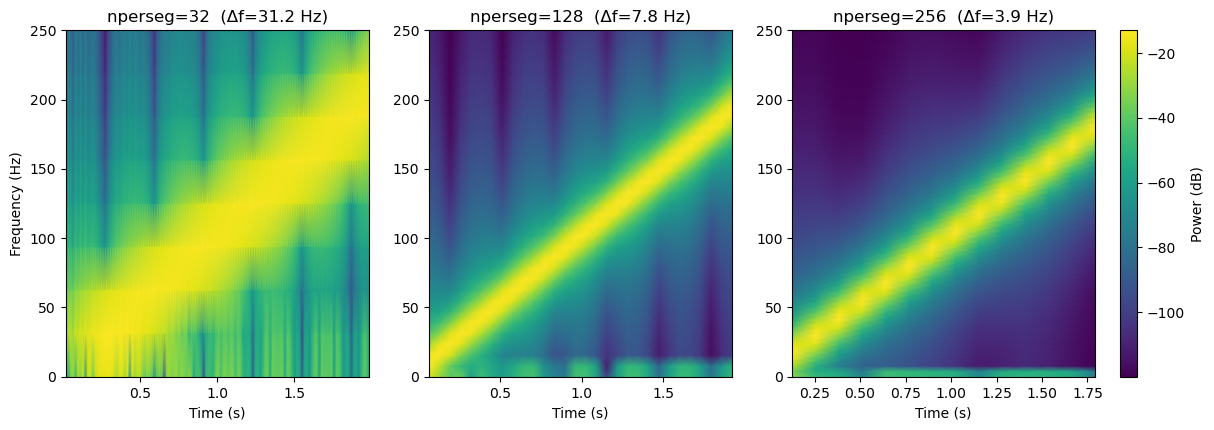

In [6]:
nperseg_list = [32, 128, 256]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, N in zip(axes, nperseg_list):
    f, t_spec, Sxx = signal.spectrogram(
        x, fs=fs, nperseg=N, noverlap=N // 2, nfft=N, window='hann')
    pcm = ax.pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-12),
                        shading='gouraud', cmap='viridis')
    ax.set_title(f'nperseg={N}  (Δf={fs/N:.1f} Hz)')
    ax.set_xlabel('Time (s)')
    ax.set_ylim([0, 250])

axes[0].set_ylabel('Frequency (Hz)')
fig.colorbar(pcm, ax=axes.tolist(), label='Power (dB)', pad=0.02)
plt.show()

- `nperseg=32`: chirp 궤적이 세로로 뭉개짐 (주파수 해상도 부족)
- `nperseg=256`: chirp 궤적이 가로로 길게 번짐 (시간 해상도 부족)
- `nperseg=128`: 두 해상도의 균형점

### 직접 해보기
`nperseg_list`에 `512`를 추가해 보라. 주파수 해상도는 더 좋아지지만 chirp의 시작·끝이 어떻게 번지는지 확인한다.

---

## 실습 5. 오버랩 `noverlap` 변화

`noverlap` 을 늘리면 프레임 간 중첩이 커져 시간축이 매끄러워진다. 일반적으로 **50~75%** 권장.

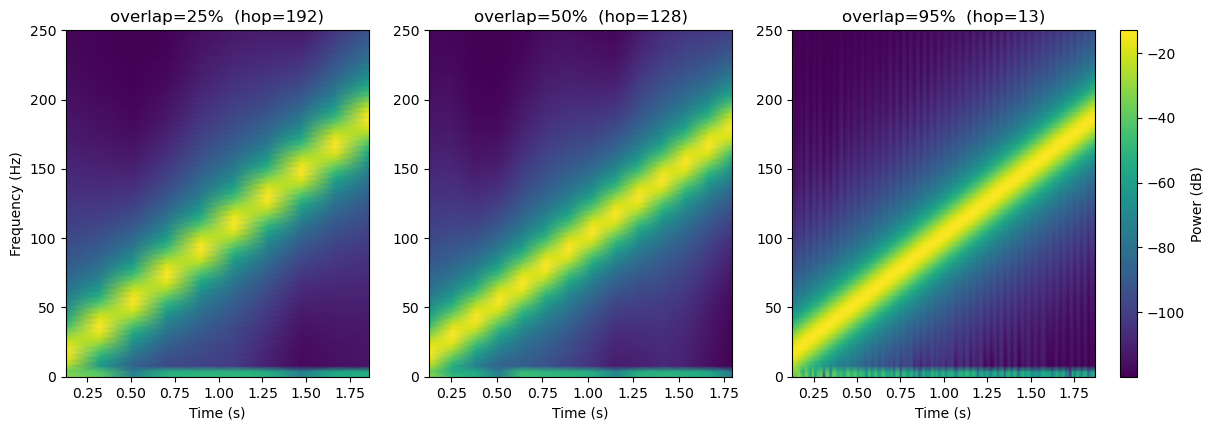

In [7]:
nperseg = 256
overlap_ratios = [0.25, 0.50, 0.95]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, r in zip(axes, overlap_ratios):
    noverlap = int(nperseg * r)
    f, t_spec, Sxx = signal.spectrogram(
        x, fs=fs, nperseg=nperseg, noverlap=noverlap,
        nfft=nperseg, window='hann')
    pcm = ax.pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-12),
                        shading='gouraud', cmap='viridis')
    ax.set_title(f'overlap={int(r*100)}%  (hop={nperseg - noverlap})')
    ax.set_xlabel('Time (s)')
    ax.set_ylim([0, 250])

axes[0].set_ylabel('Frequency (Hz)')
fig.colorbar(pcm, ax=axes.tolist(), label='Power (dB)', pad=0.02)
plt.show()

오버랩이 25%에서 95%로 증가할수록 시간축 방향 '계단' 모양이 사라지고 궤적이 매끄러워진다. 일반적으로 **50~75%**가 적절한 선택이다.

---

## 실습 6. `nfft` 변화 (제로패딩 효과)

`nfft > nperseg` 로 두면 실제 FFT 크기는 제로패딩으로 늘어난다. 그림은 부드러워지지만 **실제 주파수 해상도는 nperseg 에 의해 결정**된다.

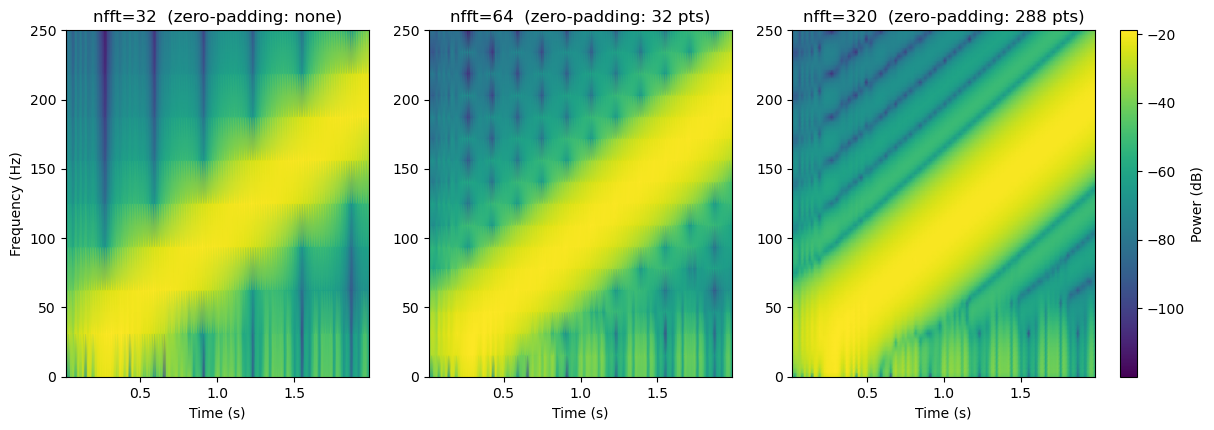

In [8]:
nperseg = 32
noverlap = 16
nfft_list = [32, 64, 320]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, nfft in zip(axes, nfft_list):
    f, t_spec, Sxx = signal.spectrogram(
        x, fs=fs, nperseg=nperseg, noverlap=noverlap,
        nfft=nfft, window='hann')
    pcm = ax.pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-12),
                        shading='gouraud', cmap='viridis')
    zp = 'none' if nfft == nperseg else f'{nfft - nperseg} pts'
    ax.set_title(f'nfft={nfft}  (zero-padding: {zp})')
    ax.set_xlabel('Time (s)')
    ax.set_ylim([0, 250])

axes[0].set_ylabel('Frequency (Hz)')
fig.colorbar(pcm, ax=axes.tolist(), label='Power (dB)', pad=0.02)
plt.show()

`nfft`를 키우면 그림은 부드러워 보이지만, `nperseg=32`가 만들어내는 31.25 Hz의 **실제** 해상도 한계는 변하지 않는다. 두꺼운 가로 줄무늬가 그대로 남아 있다.

Good 쪽에서는 chirp의 선형 궤적이 또렷이 보인다. 실전에서는 **Good 파라미터를 먼저 시도하고, 필요에 따라 조정**하는 것이 좋다.

### 직접 해보기
Poor 설정에서 `nperseg`만 128로 바꾸고 `nfft`, `noverlap`을 그대로 두면 스펙트로그램이 얼마나 개선되는지 비교한다.

---

## 실습 7. 실제 오디오 — knocking.mp3

실제 오디오에서도 STFT 파라미터가 결과 품질을 좌우한다. `knocking.mp3` 를 불러와 파형을 보고, **Poor 파라미터** (시간·주파수 해상도 부족) 와 **Good 파라미터** (1024 pt, 75% overlap) 를 나란히 비교한다. Good 쪽에서 각 타격의 어택과 공진 대역이 선명히 드러난다.

Sampling Frequency: 44100 Hz, Duration: 1.18 s


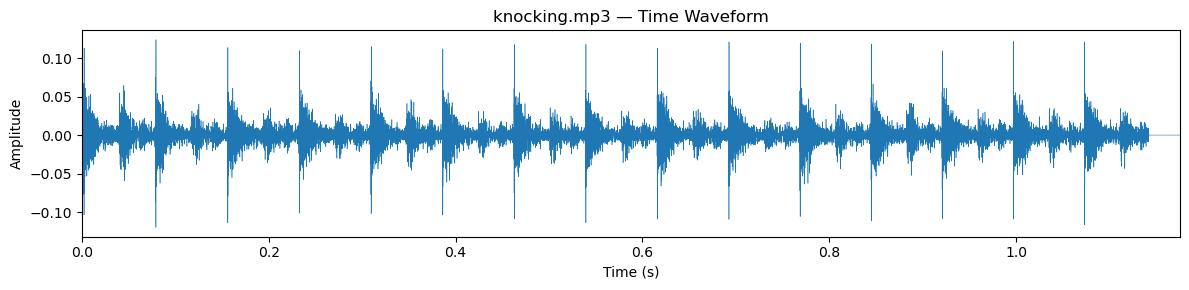

In [9]:
try:
    import librosa
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'librosa'])
    import librosa

# 오디오 로드 (sr=None 이면 파일 원본 샘플링 레이트 유지)
audio, fs_audio = librosa.load('./data/knocking.mp3', sr=None, mono=True)
print(f'Sampling Frequency: {fs_audio} Hz, Duration: {len(audio)/fs_audio:.2f} s')

t_audio = np.arange(len(audio)) / fs_audio
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_audio, audio, color='C0', linewidth=0.4)
ax.set_title('knocking.mp3 — Time Waveform')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_xlim([0, t_audio[-1]])
plt.tight_layout()
plt.show()

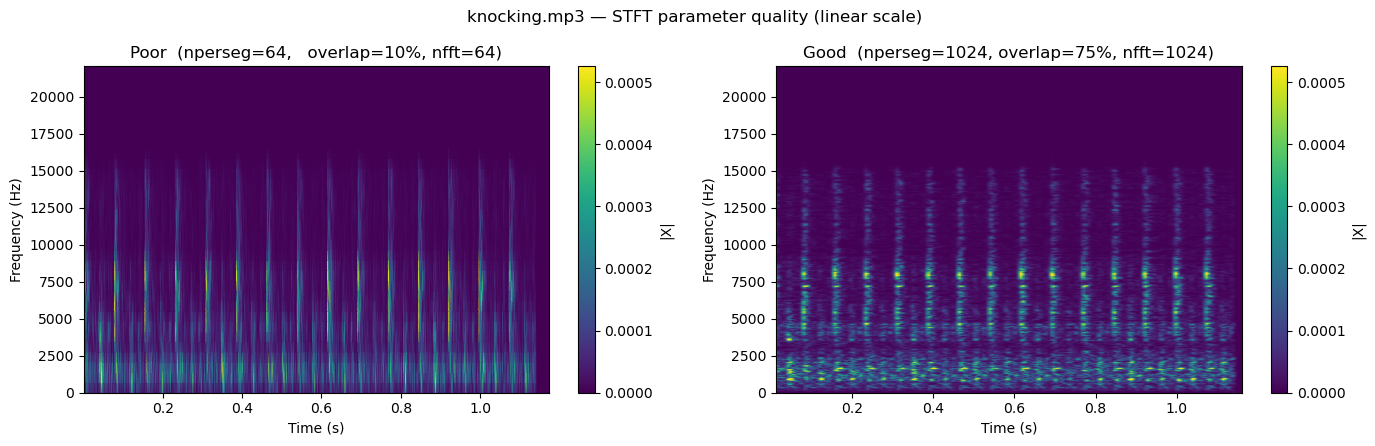

In [10]:
from scipy.signal import spectrogram as _spec

# 두 파라미터 세트
configs = [
    ('Poor  (nperseg=64,   overlap=10%, nfft=64)',   64,   int(64*0.10),   64),
    ('Good  (nperseg=1024, overlap=75%, nfft=1024)', 1024, int(1024*0.75), 1024),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
vmax_lin = None
spec_results = []
for nps, nov, nf in [(c[1], c[2], c[3]) for c in configs]:
    f_k, t_k, S_k = _spec(audio, fs=fs_audio, nperseg=nps, noverlap=nov, nfft=nf, window='hann')
    S_mag = np.sqrt(S_k)   # amplitude (linear)
    spec_results.append((f_k, t_k, S_mag))
    vmax_lin = max(vmax_lin, S_mag.max()) if vmax_lin else S_mag.max()

for ax, (label, _, _, _), (f_k, t_k, S_mag) in zip(axes, configs, spec_results):
    pcm = ax.pcolormesh(t_k, f_k, S_mag, shading='gouraud', cmap='viridis',
                        vmin=0, vmax=vmax_lin * 0.5)
    ax.set_ylim(0, fs_audio/2)
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Frequency (Hz)')
    ax.set_title(label)
    fig.colorbar(pcm, ax=ax, label='|X|')

fig.suptitle('knocking.mp3 — STFT parameter quality (linear scale)')
plt.tight_layout(); plt.show()

**관찰**:
- **Poor (nperseg=64, overlap 10%)**: 윈도우가 너무 짧아 $\Delta f = f_s/64$ 로 주파수 해상도가 낮고, 오버랩이 적어 시간축도 블록 형태로 거칠다. 타격 시점은 대략 보이지만 공진 대역이 넓게 번진다.
- **Good (nperseg=1024, overlap 75%)**: 각 타격의 **어택 + 감쇠 곡선** 과 공진 주파수 대역이 선명히 드러난다. **주기적 impulse** 구조가 TF 상에서 또렷이 보인다.
- 실전에서는 **신호 특성 (임펄스성 vs 정상상태)** 에 맞춰 nperseg 를 주요 시간 스케일과 유사하게 두고 overlap 은 50~75% 로 잡는다.

---

## 실습 8. CWT — 연속 웨이블릿 변환

CWT 는 스케일(=주파수) 에 따라 윈도우 길이를 **자동으로 조정**한다. 저주파 영역에서는 주파수 해상도가, 고주파 영역에서는 시간 해상도가 상대적으로 더 좋아진다 (multi-resolution analysis).

In [11]:
try:
    import pywt
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'PyWavelets'])
    import pywt

# Part A의 chirp 신호를 그대로 사용 (fs=1000 Hz, 5->200 Hz, 2초)
wavelet = 'morl'
fc = pywt.central_frequency(wavelet)
dt = 1.0 / fs

# 분석할 주파수 범위: 1~250 Hz → 로그 간격 스케일
f_min, f_max = 1.0, 250.0
scale_min = fc / (f_max * dt)
scale_max = fc / (f_min * dt)
scales = np.logspace(np.log10(scale_min), np.log10(scale_max), 150)

coefs, freqs_cwt = pywt.cwt(x, scales, wavelet, sampling_period=dt)
power = np.abs(coefs) ** 2
print(f'CWT coefficients shape: {coefs.shape}  (scales × samples)')

CWT coefficients shape: (150, 2000)  (scales × samples)


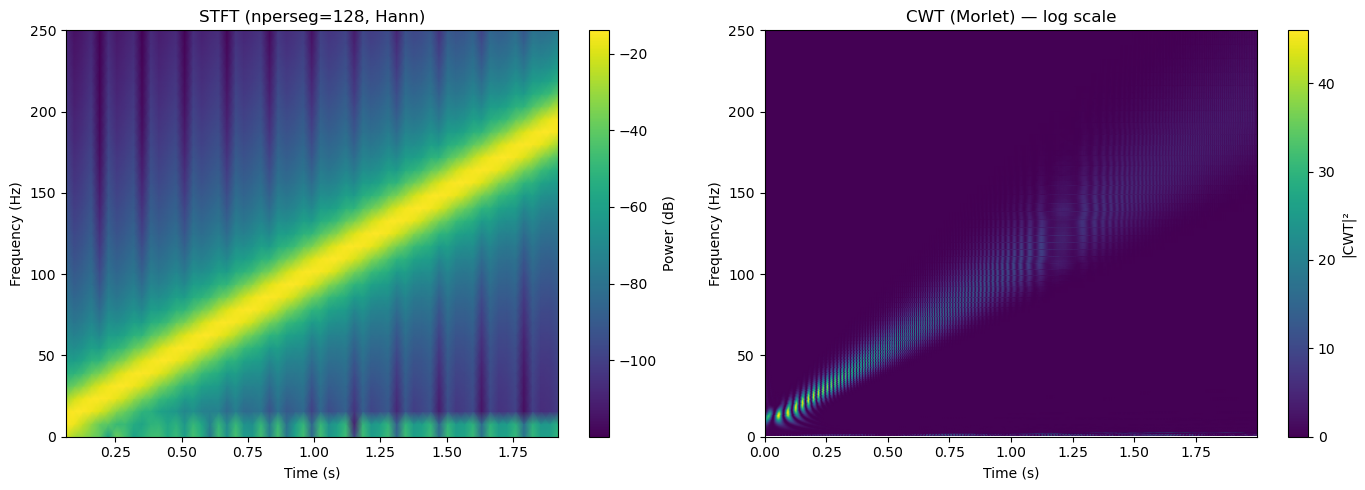

In [12]:
# CWT vs STFT(nperseg=128) 나란히 비교
nperseg = 128
f_stft, t_stft, Sxx = signal.spectrogram(
    x, fs=fs, nperseg=nperseg, noverlap=nperseg * 3 // 4,
    nfft=nperseg, window='hann')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pcm0 = axes[0].pcolormesh(t_stft, f_stft, 10 * np.log10(Sxx + 1e-12),
                          shading='gouraud', cmap='viridis')
axes[0].set_title(f'STFT (nperseg={nperseg}, Hann)')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_ylim([0, 250])
fig.colorbar(pcm0, ax=axes[0], label='Power (dB)')

pcm1 = axes[1].pcolormesh(t, freqs_cwt, power,
                          shading='gouraud', cmap='viridis')
axes[1].set_title('CWT (Morlet) — log scale')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_ylim([0, 250])
fig.colorbar(pcm1, ax=axes[1], label='|CWT|²')

plt.tight_layout()
plt.show()

CWT는 저주파 영역에서 주파수 해상도가, 고주파 영역에서 시간 해상도가 상대적으로 더 좋다. 이를 **다중해상도 분석(Multi-Resolution Analysis)**이라 한다.

### 직접 해보기
`scales`를 `np.logspace(np.log10(scale_min), np.log10(scale_max), 50)`으로 줄이면 세로축(주파수축) 샘플링이 어떻게 거칠어지는지 확인한다.

---

## 실습 9. DWT 기반 디노이징

DWT 로 신호를 여러 스케일로 분해하면, 저주파 신호는 **근사 계수(cA)** 에 모이고 광대역 노이즈는 모든 **세부 계수(cD)** 에 퍼진다. 여기에 **표준 VisuShrink** 를 적용한다 — 잡음 표준편차를 가장 미세한 세부 계수에서 추정(MAD)하고, **universal threshold** $\lambda = \hat\sigma\sqrt{2\ln N}$ 을 **모든 세부 계수에 일괄** soft-threshold 한다. 작은 노이즈 계수는 0 으로 사라지고 큰 신호 계수는 살아남아, 어느 대역이 노이즈인지 미리 알 필요 없이 노이즈가 제거된다.

In [ ]:
# 합성 신호: 5 + 15 + 40 Hz 저주파 신호 + 가우시안 노이즈
np.random.seed(42)
fs_dn = 1000
T_dn = 1.0
t_dn = np.arange(0, T_dn, 1 / fs_dn)
N = len(t_dn)

x_clean = (np.sin(2 * np.pi * 5 * t_dn)
           + 0.5 * np.sin(2 * np.pi * 15 * t_dn)
           + 0.8 * np.sin(2 * np.pi * 40 * t_dn))
sigma = 0.4
x_noisy = x_clean + sigma * np.random.randn(N)

# DWT 3레벨 분해 (db8)
#   fs=1000, level=3 이론적 대역:
#     cA3 : 0 ~ 62.5 Hz — 신호(5, 15, 40 Hz)가 모두 이 근사 대역에 있음
#     cD3/cD2/cD1 : 62.5 Hz 이상 — 노이즈 위주
wavelet = 'db8'
level = 3
coeffs = pywt.wavedec(x_noisy, wavelet, level=level)
cA3, cD3, cD2, cD1 = coeffs

# 각 레벨의 계수 통계 — cA3(신호)만 std 가 크고, 나머지 detail 은 노이즈 수준임을 확인
for name, coef in [('cA3', cA3), ('cD3', cD3), ('cD2', cD2), ('cD1', cD1)]:
    print(f'  {name}: len={len(coef):4d}, std={np.std(coef):.3f}, max|.|={np.max(np.abs(coef)):.3f}')

# 잡음 크기(표준편차) 추정 — 노이즈가 지배적인 가장 미세한 세부 계수(cD1)에서 추정한다.
#   median(|cD1|)/0.6745 : 가우시안에서 중앙값 절댓값과 sigma 의 관계로 sigma 를 환산.
sigma_hat = np.median(np.abs(cD1)) / 0.6745
# 임계값: 잡음 계수가 거의 넘지 못하는 높이 = sigma * sqrt(2 ln N)
lam = sigma_hat * np.sqrt(2 * np.log(N))
print(f'Estimated noise sigma = {sigma_hat:.4f}  (true sigma = {sigma})')
print(f'Universal threshold lambda = {lam:.4f}')

# 근사 계수(cA3, 신호)는 그대로 두고, 세부 계수(노이즈)에만 soft-threshold 적용.
# 임계값보다 작은 계수는 0, 큰 계수는 임계값만큼 줄여서 복원한다.
coeffs_thr = [cA3] + [pywt.threshold(c, lam, mode='soft') for c in (cD3, cD2, cD1)]
x_denoised = pywt.waverec(coeffs_thr, wavelet)[:N]

# SNR 비교
def snr_db(clean, meas):
    noise = meas - clean
    return 10 * np.log10(np.mean(clean ** 2) / (np.mean(noise ** 2) + 1e-12))

snr_before = snr_db(x_clean, x_noisy)
snr_after  = snr_db(x_clean, x_denoised)
print(f'SNR: {snr_before:.2f} dB  ->  {snr_after:.2f} dB  (improvement +{snr_after - snr_before:.2f} dB)')

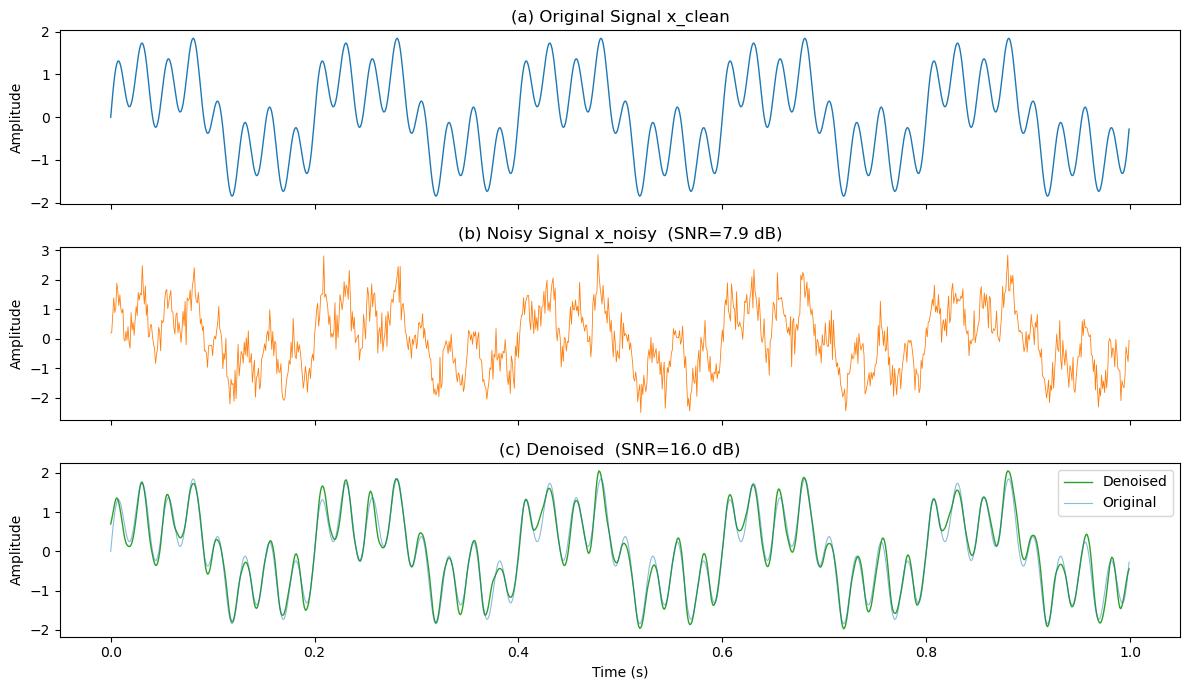

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(t_dn, x_clean, color='C0', linewidth=1.0)
axes[0].set_title('(a) Original Signal x_clean')
axes[0].set_ylabel('Amplitude')

axes[1].plot(t_dn, x_noisy, color='C1', linewidth=0.6)
axes[1].set_title(f'(b) Noisy Signal x_noisy  (SNR={snr_before:.1f} dB)')
axes[1].set_ylabel('Amplitude')

axes[2].plot(t_dn, x_denoised, color='C2', linewidth=1.0, label='Denoised')
axes[2].plot(t_dn, x_clean, color='C0', linewidth=0.8, alpha=0.5, label='Original')
axes[2].set_title(f'(c) Denoised  (SNR={snr_after:.1f} dB)')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Amplitude')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

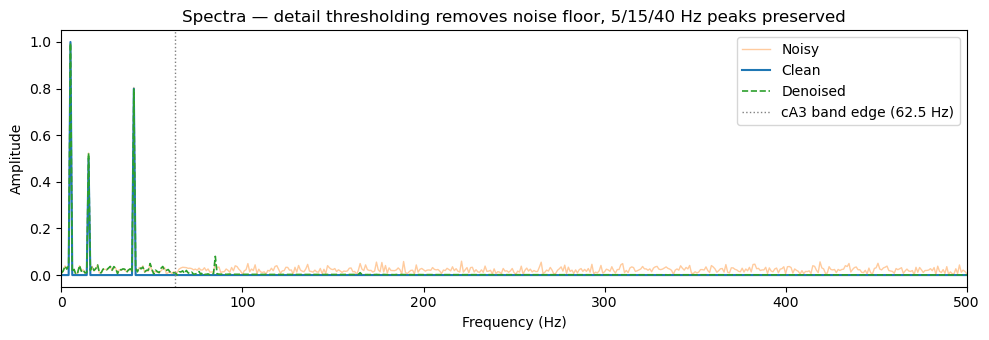

In [15]:
# 디노이징 효과를 스펙트럼에서 확인
f_c, A_c = fft(x_clean,    fs_dn)
f_n, A_n = fft(x_noisy,    fs_dn)
f_d, A_d = fft(x_denoised, fs_dn)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(f_n, A_n, color='C1', alpha=0.4, lw=1.0, label='Noisy')
ax.plot(f_c, A_c, color='C0',             lw=1.5, label='Clean')
ax.plot(f_d, A_d, color='C2',             lw=1.2, ls='--', label='Denoised')
ax.set_xlim(0, 500); ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Amplitude')
ax.axvline(62.5, color='gray', ls=':', lw=1.0, label='cA3 band edge (62.5 Hz)')
ax.set_title('Spectra — detail thresholding removes noise floor, 5/15/40 Hz peaks preserved')
ax.legend(); fig.tight_layout(); plt.show()

**관찰**:
- DWT 는 신호를 저주파 **근사 성분**과 여러 고주파 **세부 성분**으로 나눈다. 5/15/40 Hz 는 모두 저주파라 근사 성분에 모이고, 노이즈는 세부 성분 전체에 퍼진다.
- 세부 성분에 soft-threshold 를 적용하면 진폭이 작은 노이즈 계수는 0 이 되고 큰 신호 계수는 남는다. 그 결과 세 피크는 그대로 유지되면서 노이즈 플로어만 낮아져 SNR 이 약 8 dB **개선**된다.
- 데이터에서 추정한 잡음 크기 $\hat\sigma \approx 0.42$ 가 실제 $\sigma = 0.4$ 와 잘 맞는다.

---

## 정리

본 노트북에서는 시간에 따라 변하는 신호를 분석하는 **STFT / CWT / DWT** 세 가지 도구를 익혔다.

- **STFT**: 고정 윈도우 → 시간/주파수 해상도 트레이드오프 (`nperseg`, `noverlap`, `nfft` 제어)
- **CWT**: 스케일에 따라 윈도우 길이 자동 조정 → 다중 해상도 분석
- **DWT**: 다단계 이진 분해 + 소프트 임계처리 → 디노이징
